# Best tSZ power spectrum

tsz_all.shape = (351, 512, 512)
ksz_all.shape = (351, 512, 512)
cib_all.shape = (351, 512, 512)
A_tsz = 1.94687930231972
B_tsz = -7.079570746267914e-07
tsz_all_log.shape = (351, 512, 512)
mixed_target.shape = (10, 3, 512, 512)
centered_target.shape = (10, 3, 512, 512)
channel_means.shape   = (10, 3, 1, 1)
Running synthesis on device : cuda:0 dtype : torch.float64
Initial shape for u: (10, 3, 512, 512)
Synthesis on MAIN 35766 coefficients
Replacing existing var_ref in ST_Op
Replacing existing S2_ref_sqrt_chan_diag in ST_Op
Synthesis on EXP-PS 192 coefficients
Synthesis on EXP-SCAT 35574 coefficients
[LBFGS] inner iter 100, loss = 3.393961e+02, loss_main = 1.351667e+02, loss_exp_ps = 7.317729e+01, loss_exp_scat = 1.310521e+02
[LBFGS] inner iter 200, loss = 2.562971e+02, loss_main = 1.122740e+02, loss_exp_ps = 5.878534e+01, loss_exp_scat = 8.523778e+01
[LBFGS] inner iter 300, loss = 2.084074e+02, loss_main = 9.760274e+01, loss_exp_ps = 5.557384e+01, loss_exp_scat = 5.523085e+01
[LBFGS] in

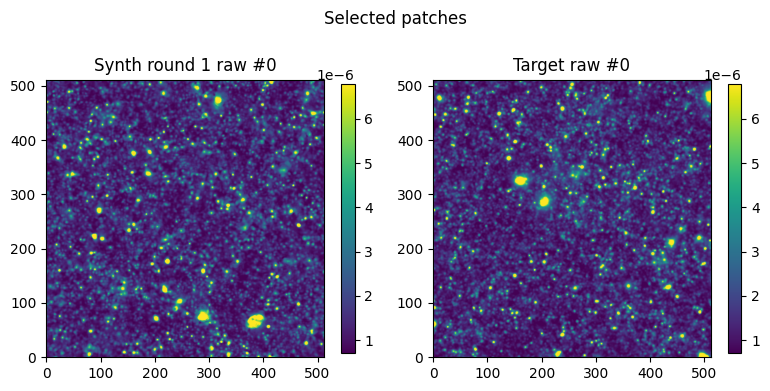

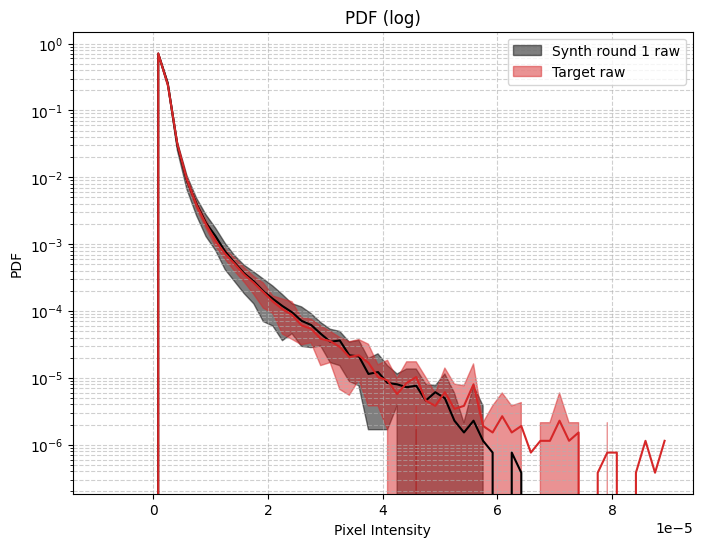

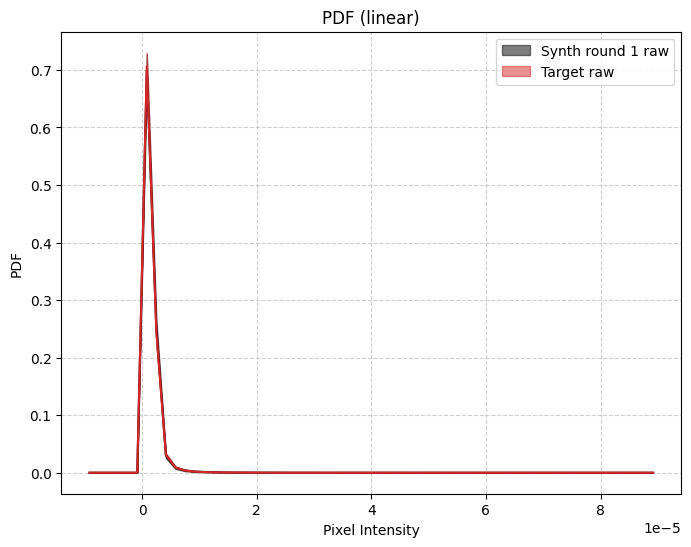

[DEBUG PS] Synth round 1 raw min= 3.111759718466811e-10 max= 0.0001345237341349096 any>0? True any nan? False shape= (10, 252)
[DEBUG PS] Target raw min= 5.216819707338482e-10 max= 0.00021524933011119927 any>0? True any nan? False shape= (10, 252)


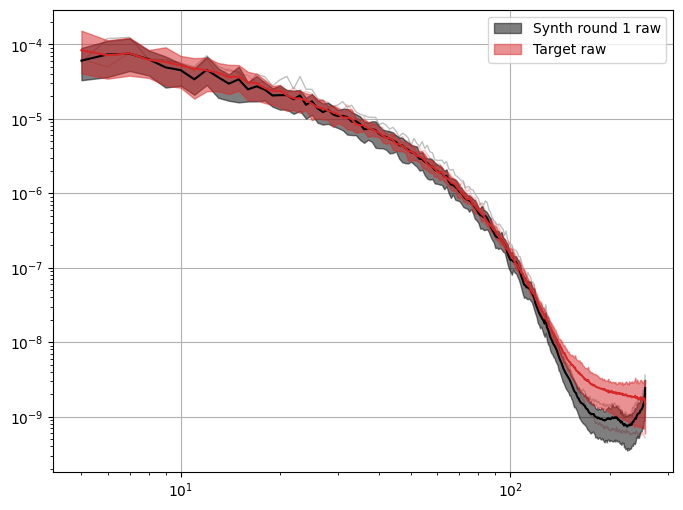

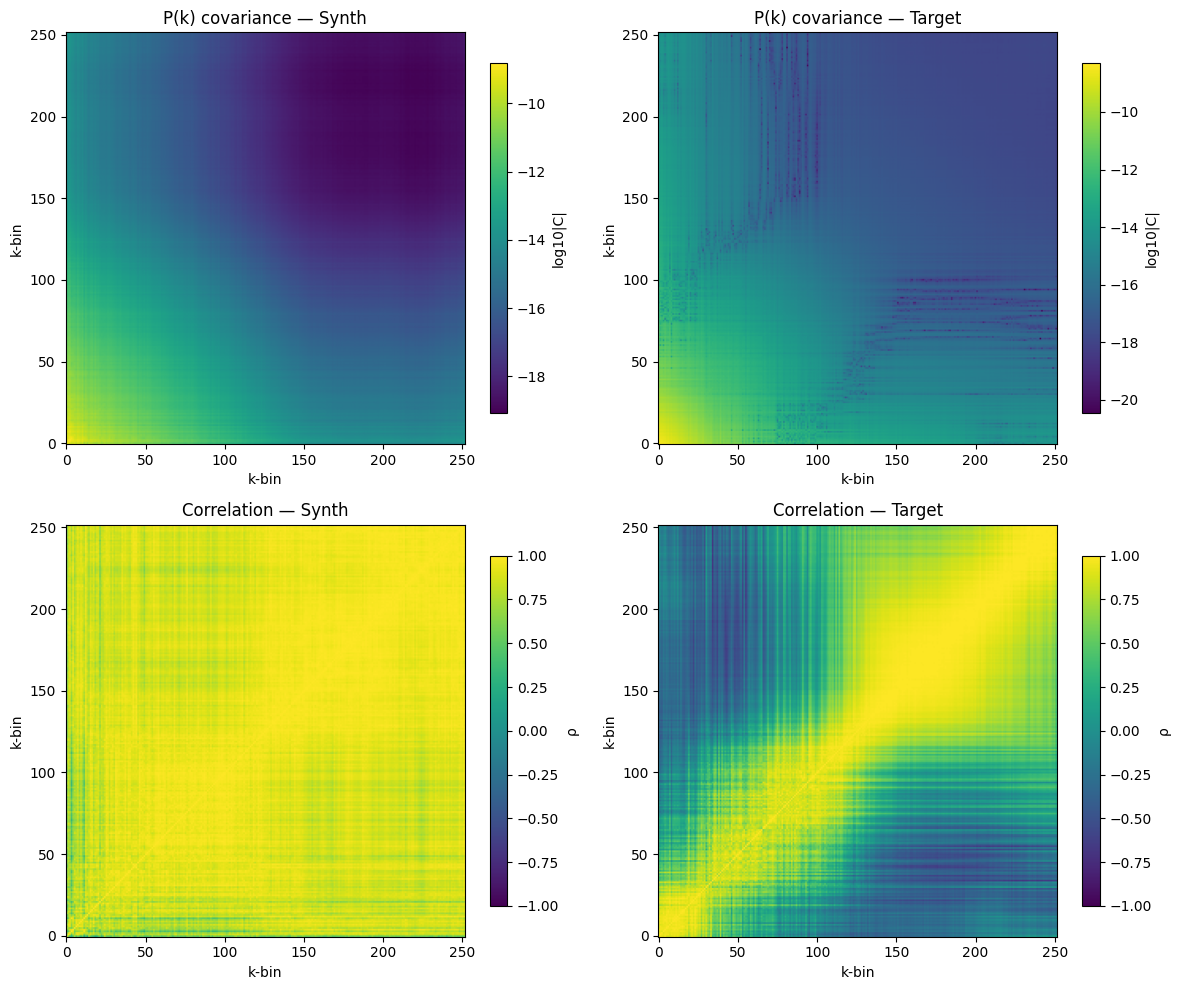

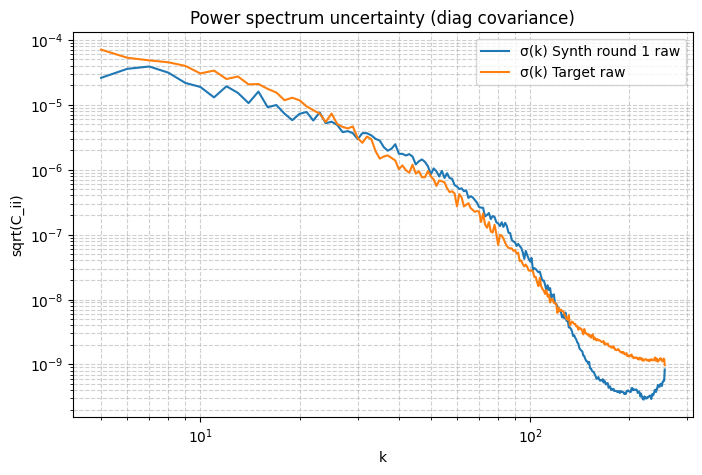

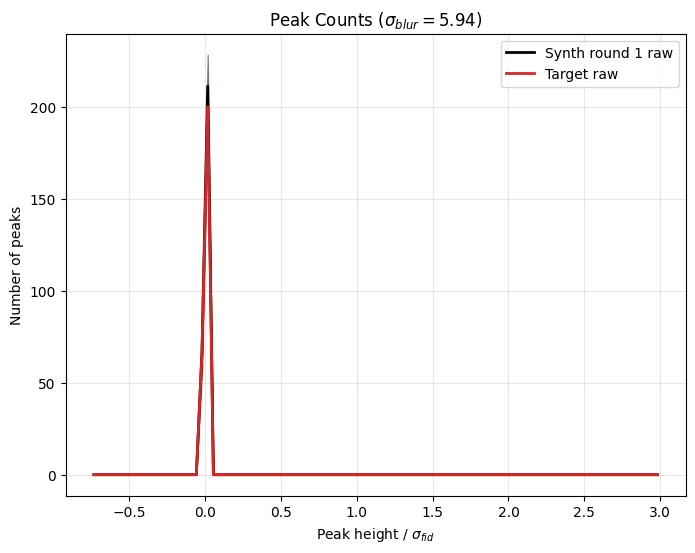

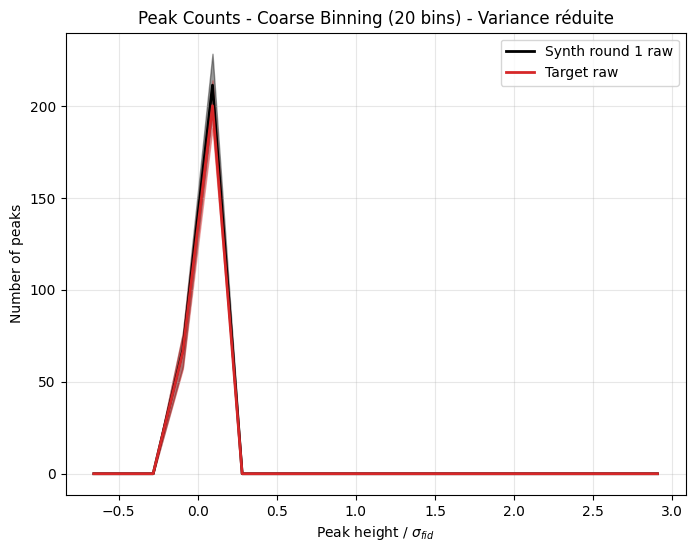

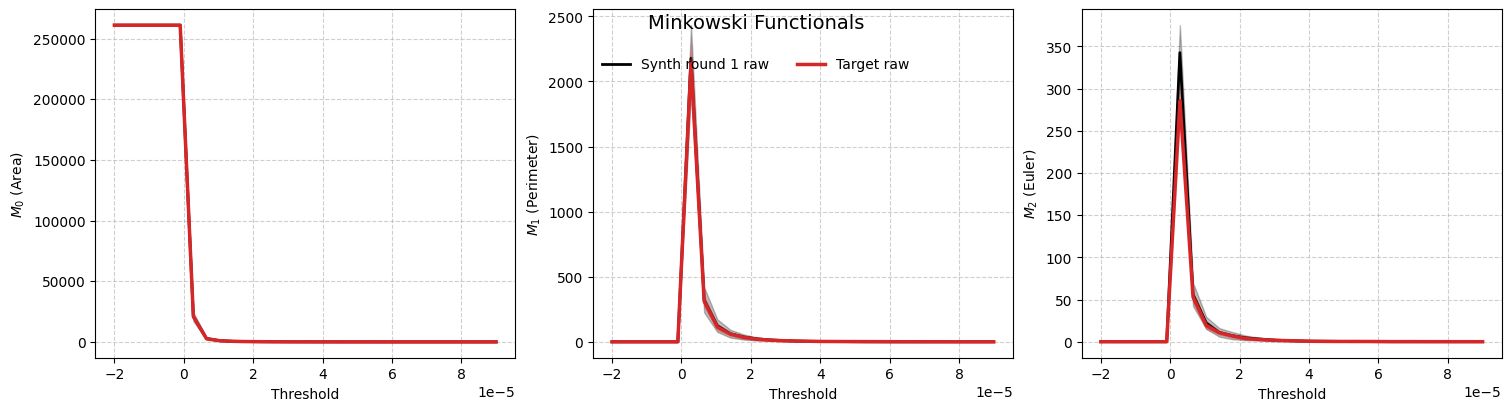

{'n_folders': 2,
 'counts': [10, 10],
 'labels': ['Synth round 1 raw', 'Target raw'],
 'colors': ['black', 'tab:red'],
 'gaussian_mode': 'disabled',
 'gaussian_source_index': None,
 'gaussian_color': 'black'}

In [2]:
import os
import sys
import numpy as np
import torch

# =========================================================
# Paths / imports
# =========================================================
chemin_stl_dev = os.path.join(os.getcwd(), "STL_104")
sys.path.append(os.getcwd())
sys.path.append(chemin_stl_dev)
sys.path.append("/rds/rds-clecat/generative_modelling/STL_104")

from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch
from STL_main.Synthesis_PS_ST import synthesize_from_maps
from clean_utils import find_parameters, flexible_analysis


# =========================================================
# Paramètres généraux
# =========================================================
file_base = "/rds/rds-clecat/generative_modelling/data_celia"
#base_dir = "results_mean_field_multichannel_logspace" => when init with results already converged 
base_dir = "results_20patches_29_05_cv_2000"
n_sets = 10
nbatch = 10
mean_field = True
eps = 1e-11

os.makedirs(base_dir, exist_ok=True)


# =========================================================
# Utilitaires
# =========================================================
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def save_three_channels(arr, out_base):
    """
    arr shape = (N, 3, H, W)
    channel 0 = tsz
    channel 1 = ksz
    channel 2 = cib
    """
    tsz_dir = os.path.join(out_base, "tsz")
    ksz_dir = os.path.join(out_base, "ksz")
    cib_dir = os.path.join(out_base, "cib")

    for d in [tsz_dir, ksz_dir, cib_dir]:
        os.makedirs(d, exist_ok=True)

    for i in range(arr.shape[0]):
        np.save(os.path.join(tsz_dir, f"patch_{i:03d}.npy"), arr[i, 0].astype(np.float32))
        np.save(os.path.join(ksz_dir, f"patch_{i:03d}.npy"), arr[i, 1].astype(np.float32))
        np.save(os.path.join(cib_dir, f"patch_{i:03d}.npy"), arr[i, 2].astype(np.float32))


# =========================================================
# 1) Chargement des cartes physiques
# =========================================================
tsz_all = np.load(f"{file_base}/tsz_cut_maps.npy").astype(np.float64)
ksz_all = np.load(f"{file_base}/ksz_cut_maps.npy").astype(np.float64)
cib_all = np.load(f"{file_base}/cib353_cut_maps.npy").astype(np.float64)

print("tsz_all.shape =", tsz_all.shape)
print("ksz_all.shape =", ksz_all.shape)
print("cib_all.shape =", cib_all.shape)


# =========================================================
# 2) Log-normalisation sur tSZ seulement
# =========================================================
A_tsz, B_tsz = find_parameters(tsz_all)
tsz_all_log = np.log(A_tsz * tsz_all + B_tsz + eps)

print("A_tsz =", A_tsz)
print("B_tsz =", B_tsz)
print("tsz_all_log.shape =", tsz_all_log.shape)


# =========================================================
# 3) Construction de la target multicanal dans l’espace log
#    canal 0 = tSZ_log
#    canal 1 = kSZ raw
#    canal 2 = CIB raw
# =========================================================
mixed_target = np.stack(
    [tsz_all_log[:n_sets], ksz_all[:n_sets], cib_all[:n_sets]],
    axis=1
)

print("mixed_target.shape =", mixed_target.shape)


# =========================================================
# 4) Centrage par canal et par patch
# =========================================================
channel_means = mixed_target.mean(axis=(-2, -1), keepdims=True)
centered_target = mixed_target - channel_means

print("centered_target.shape =", centered_target.shape)
print("channel_means.shape   =", channel_means.shape)


# =========================================================
# 5) STL target
# =========================================================
data_target = STL_2D_Kernel_Torch(centered_target, pbc=False)

compute_cross_matrix = torch.tensor([
    [1, 1, 1],
    [0, 1, 1],
    [0, 0, 1]
], dtype=torch.bool)


# =========================================================
# 6) Synthèse : espace centered/log, AVEC contrainte exp sur tSZ
# =========================================================
u_synth_1 = synthesize_from_maps(
    data_target,
    pbc_running=True,
    nbatch=nbatch,
    mean_field=mean_field,
    compute_cross_matrix=compute_cross_matrix,
    init_data=None,         #white noise => reproduce the variance
    max_iter=2000,
    lr=0.5,
    history_size=50,
    print_iter=100,
    verbose=True,
    seed=26,

    # --- parameters of double constraint, for the tSZ_log centred channel
    exp_channel=0, # apply the double constriant on the tSZ tSZ
    exp_A=A_tsz, # the parameters A and B that come from log(Ax+B)
    exp_B=B_tsz,
    exp_eps=eps, #regularization (to avoid pb in the reconstruction, set to 1e-11). Actually, it was useful when I applied log(x) instead of log(Ax+B) but now, I think I can drop it
    exp_channel_mean=channel_means[:, 0:1],   # shape (2,1,1,1)

    lambda_exp_ps=1.0, # the ponderation of the PS of the exp map in the loss (the other coefficients in the loss all have lambda = 1. This is a hyperparameter to tune. If you do syntheses in 1024 pixels, you have to set lambda << 1 otherwise the convergence is too slow).
    lambda_exp_scat=1.0, #same thing but for the scattering coefficients 
)

print("u_synth_1.shape =", u_synth_1.shape)

# =========================================================
# 7) Conversion numpy
# =========================================================
u1 = to_numpy(u_synth_1).astype(np.float64)

if u1.ndim == 3:
    u1 = u1[None, ...]

expected_shape = (
    nbatch,
    centered_target.shape[1],
    centered_target.shape[2],
    centered_target.shape[3],
)

if u1.shape != expected_shape:
    raise ValueError(f"u_synth_1 has shape {u1.shape}, expected {expected_shape}")


# =========================================================
# 8) Résultats backend = espace centré
# =========================================================
centered_results_1 = u1


# =========================================================
# 9) On remet les moyennes -> retour espace log
# =========================================================
log_results_1 = centered_results_1 + channel_means
log_target = centered_target + channel_means


# =========================================================
# 10) Délog-normalisation : retour à l’espace physique pour tSZ
# =========================================================
raw_results_1 = log_results_1.copy()
raw_target = log_target.copy()

raw_results_1[:, 0] = (np.exp(log_results_1[:, 0]) - B_tsz - eps) / A_tsz
raw_target[:, 0]    = (np.exp(log_target[:, 0])    - B_tsz - eps) / A_tsz


# =========================================================
# 11) Sauvegarde
# =========================================================
centered_target_base = os.path.join(base_dir, "centered_target")
log_target_base = os.path.join(base_dir, "log_target")
raw_target_base = os.path.join(base_dir, "raw_target")

centered_results_1_base = os.path.join(base_dir, "centered_results_1")
log_results_1_base = os.path.join(base_dir, "log_results_1")
raw_results_1_base = os.path.join(base_dir, "raw_results_1")

save_three_channels(centered_target, centered_target_base)
save_three_channels(log_target, log_target_base)
save_three_channels(raw_target, raw_target_base)

save_three_channels(centered_results_1, centered_results_1_base)
save_three_channels(log_results_1, log_results_1_base)
save_three_channels(raw_results_1, raw_results_1_base)


# =========================================================
# 12) Métadonnées
# =========================================================
np.save(os.path.join(base_dir, "A_tsz.npy"), np.array(A_tsz, dtype=np.float64))
np.save(os.path.join(base_dir, "B_tsz.npy"), np.array(B_tsz, dtype=np.float64))
np.save(os.path.join(base_dir, "channel_means.npy"), channel_means.astype(np.float64))

print("Tout est sauvegardé dans :", base_dir)
print("  centered_target    ->", centered_target_base)
print("  log_target         ->", log_target_base)
print("  raw_target         ->", raw_target_base)
print("  centered_results_1 ->", centered_results_1_base)
print("  log_results_1      ->", log_results_1_base)
print("  raw_results_1      ->", raw_results_1_base)


# =========================================================
# 13) Analyse tSZ en espace physique
# =========================================================
flexible_analysis(
    [
        os.path.join(raw_results_1_base, "tsz"),
        os.path.join(raw_target_base, "tsz"),
    ],
    labels=["Synth round 1 raw", "Target raw"],
    colors=["black", "tab:red"],
    ps_kmin=5,
    ps_kmax=256,
    ps_plot_individual_n=1,
    imshow_indices=[0, 0],
    pdf_bins=60,
    pdf_range=(-1e-5, 9e-5),
    gaussian=False,
    show=True,
    mf_min_threshold=-2e-5,
    mf_max_threshold=9e-5,
)

Downgrade des cartes vers 256x256...
Cartes 256 sauvegardées dans : results_20patches_29_05_cv_2000_256


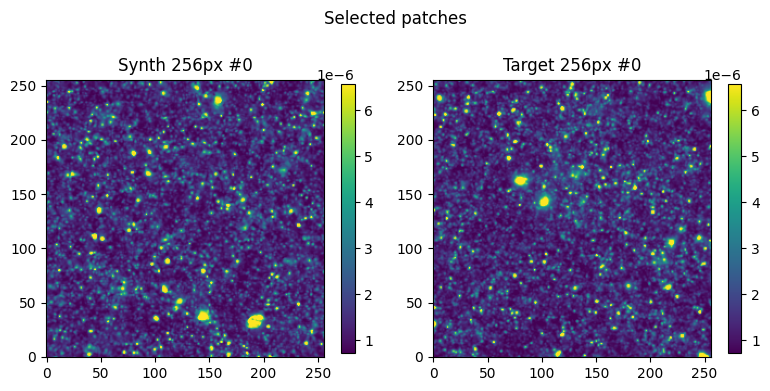

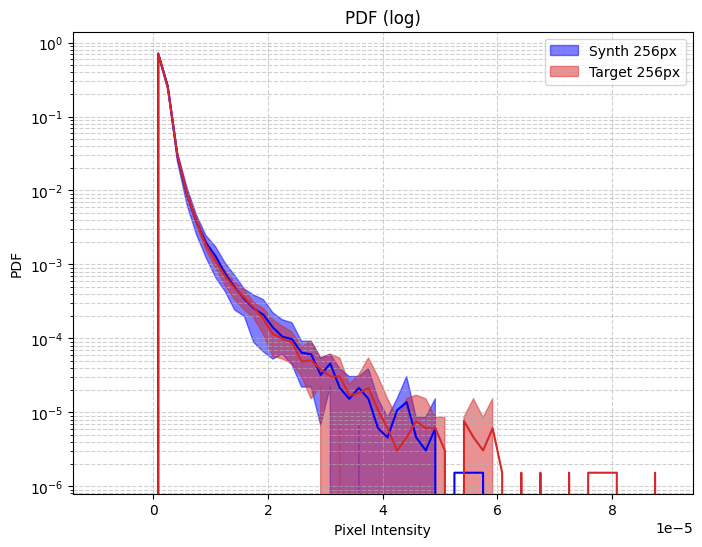

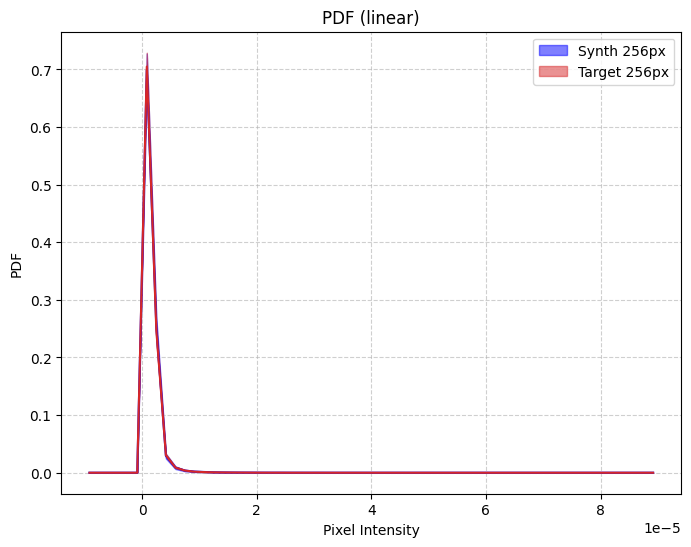

[DEBUG PS] Synth 256px min= 4.4090941065976147e-10 max= 8.39144271366801e-06 any>0? True any nan? False shape= (10, 124)
[DEBUG PS] Target 256px min= 7.132731494214952e-10 max= 1.3440384989733305e-05 any>0? True any nan? False shape= (10, 124)


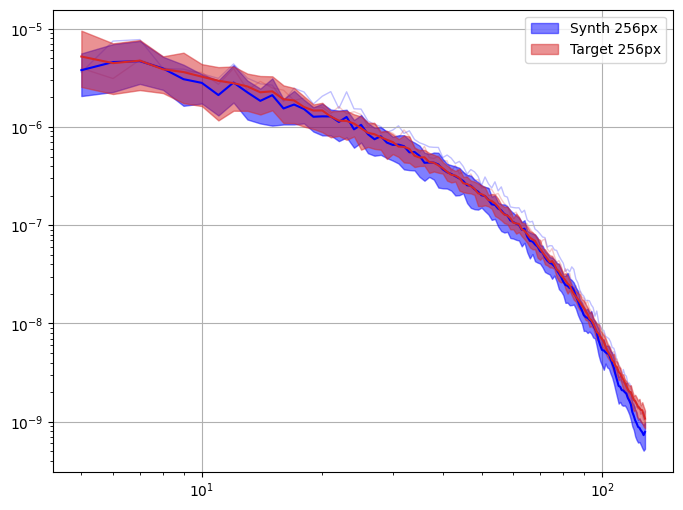

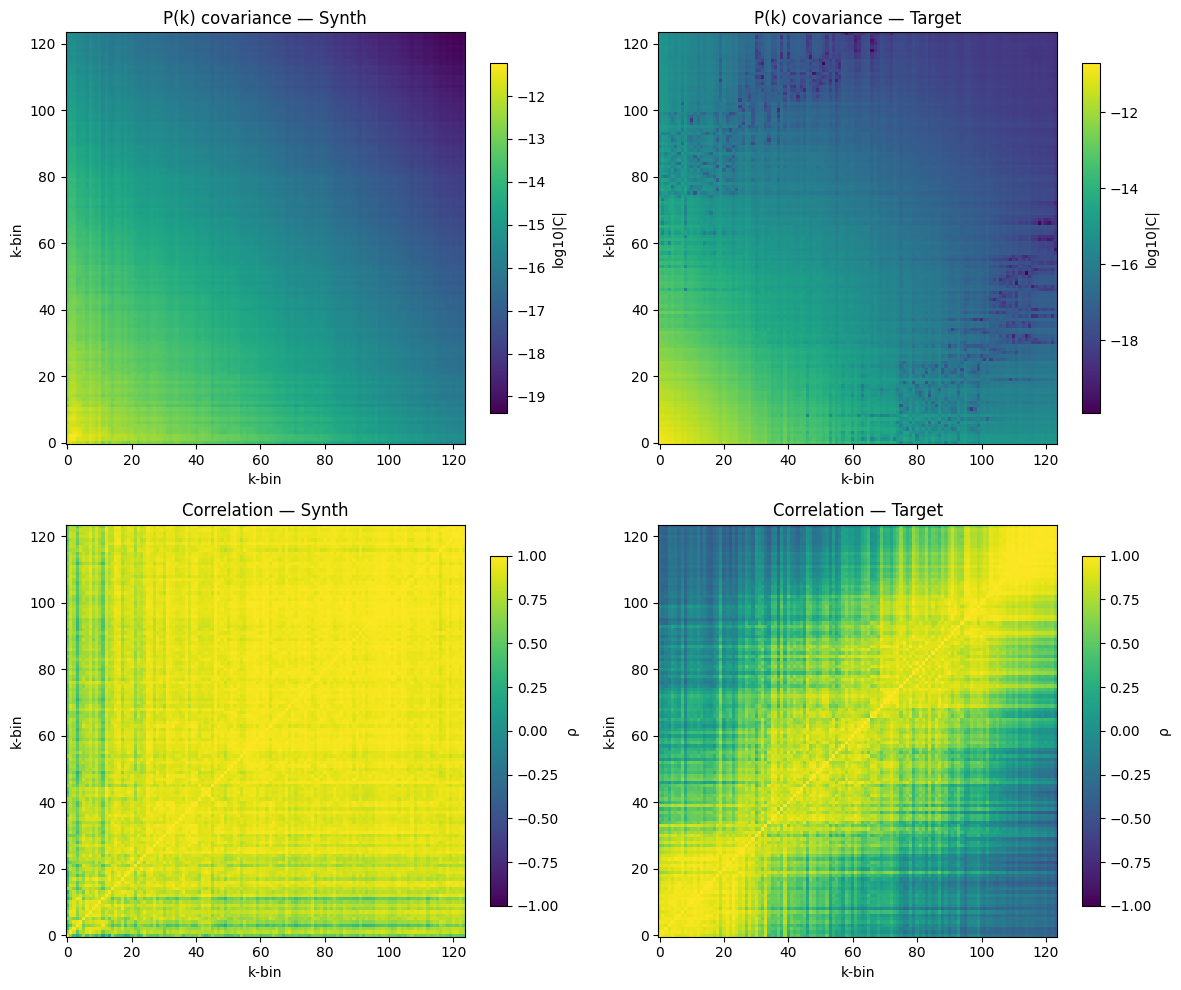

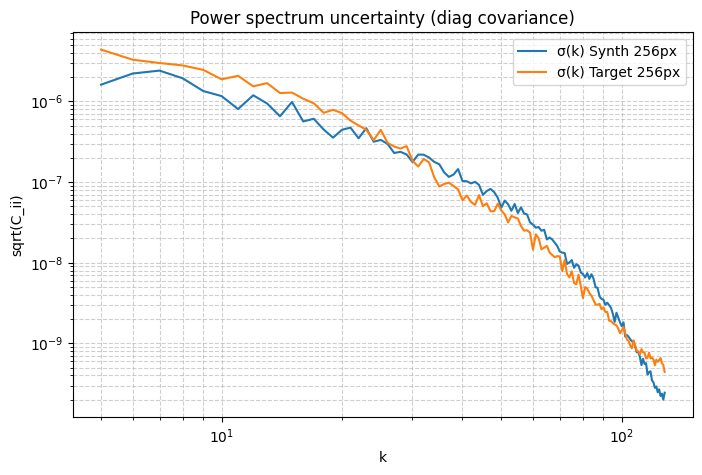

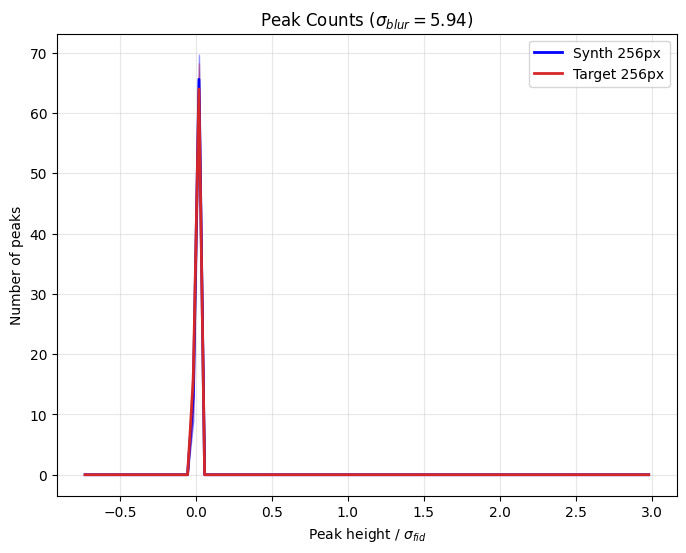

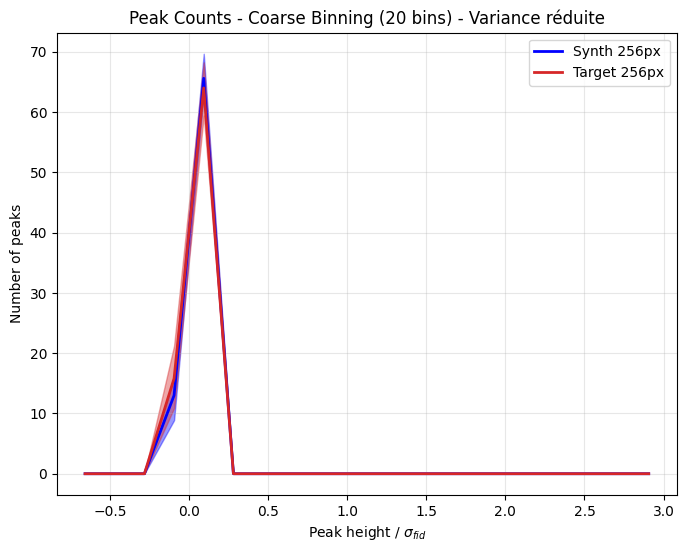

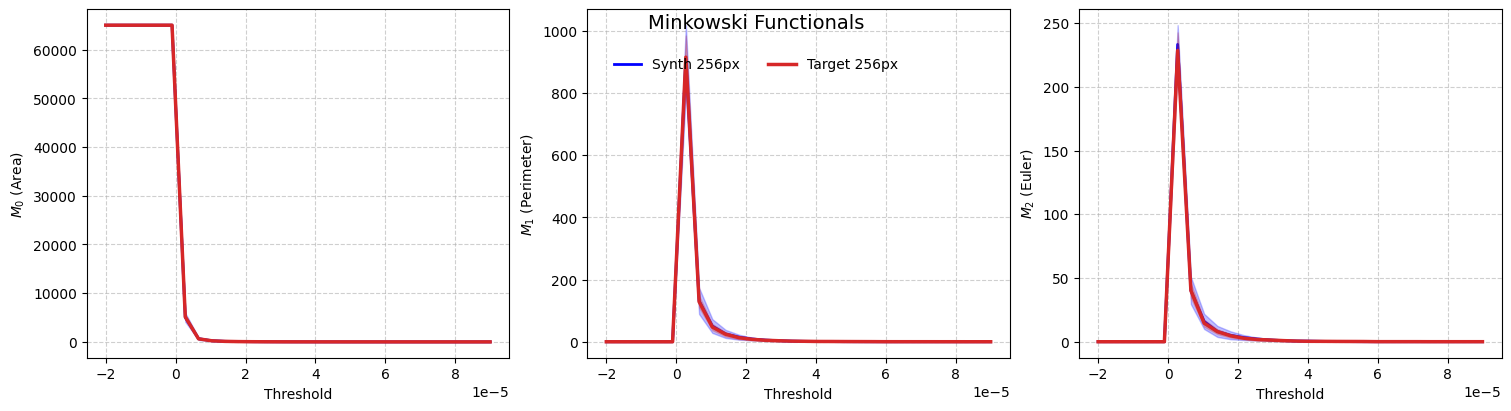

{'n_folders': 2,
 'counts': [10, 10],
 'labels': ['Synth 256px', 'Target 256px'],
 'colors': ['blue', 'tab:red'],
 'gaussian_mode': 'disabled',
 'gaussian_source_index': None,
 'gaussian_color': 'black'}

In [3]:
import torch.nn.functional as F

# =========================================================
# 14) Downgrade à 256x256 pixels
# =========================================================
new_size = 256

def downsample_batch(arr, size):
    # Conversion en tensor (N, C, H, W) si ce n'est pas déjà le cas
    tensor_in = torch.from_numpy(arr).float()
    # Interpolation (mode 'area' est souvent préférable pour le downgrade car il préserve mieux l'énergie)
    tensor_out = F.interpolate(tensor_in, size=(size, size), mode='area')
    return tensor_out.numpy().astype(np.float64)

print(f"Downgrade des cartes vers {new_size}x{new_size}...")
raw_target_256 = downsample_batch(raw_target, new_size)
raw_results_1_256 = downsample_batch(raw_results_1, new_size)

# =========================================================
# 15) Sauvegarde des versions 256
# =========================================================
base_dir_256 = base_dir + "_256"
raw_target_256_base = os.path.join(base_dir_256, "raw_target_256")
raw_results_1_256_base = os.path.join(base_dir_256, "raw_results_1_256")

save_three_channels(raw_target_256, raw_target_256_base)
save_three_channels(raw_results_1_256, raw_results_1_256_base)

print(f"Cartes 256 sauvegardées dans : {base_dir_256}")

# =========================================================
# 16) Analyse flexible sur tSZ (version 256)
# =========================================================
# Note : on ajuste ps_kmax car la fréquence de Nyquist change (256/2 = 128)
flexible_analysis(
    [
        os.path.join(raw_results_1_256_base, "tsz"),
        os.path.join(raw_target_256_base, "tsz"),
    ],
    labels=["Synth 256px", "Target 256px"],
    colors=["blue", "tab:red"],
    ps_kmin=5,
    ps_kmax=128,            # Ajusté pour 256px
    ps_plot_individual_n=1,
    imshow_indices=[0, 0],
    pdf_bins=60,
    pdf_range=(-1e-5, 9e-5),
    gaussian=False,
    show=True,
    mf_min_threshold=-2e-5,
    mf_max_threshold=9e-5,
)

Another analysis script, that does almost the same analyses as precedently but includes the (equilateral and with a wide binning) bispectrum and trispectrum

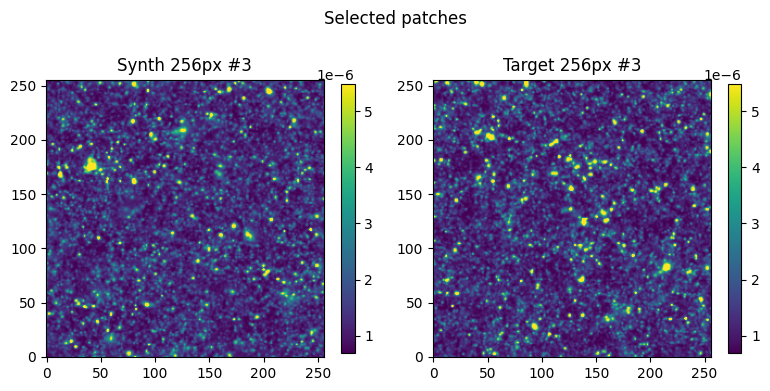

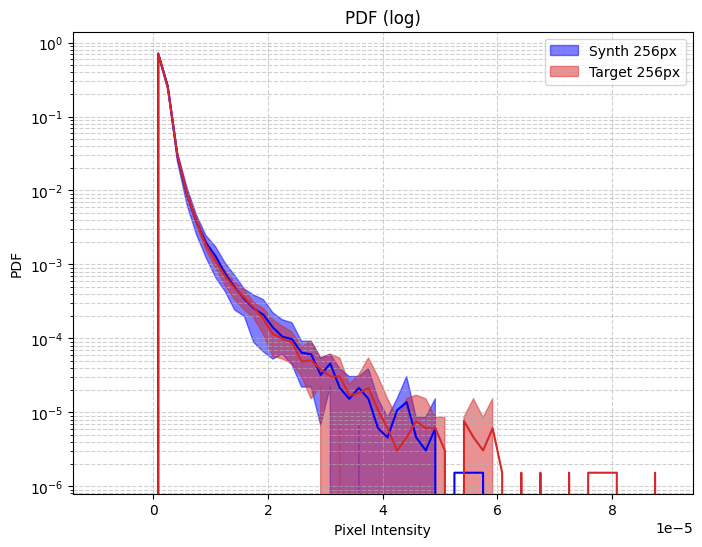

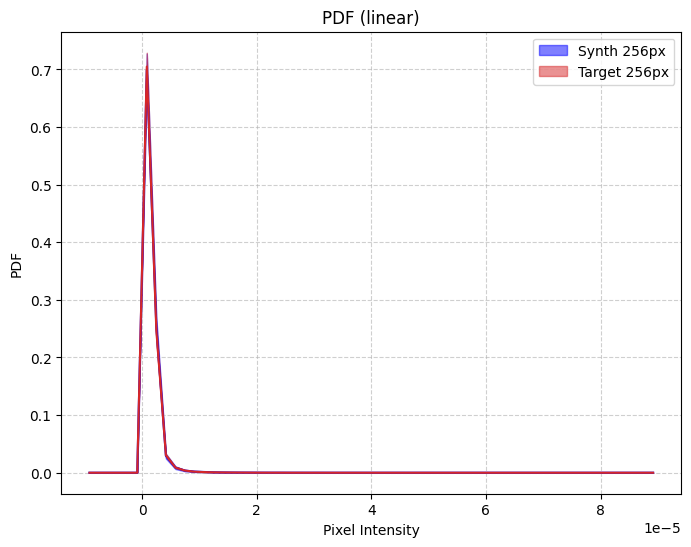

[DEBUG PS] Synth 256px min= 4.321546182983337e-10 max= 1.0354927111175377e-05 any>0? True any nan? False shape= (10, 124)
[DEBUG PS] Target 256px min= 5.555318328093209e-10 max= 1.4311383093759683e-05 any>0? True any nan? False shape= (10, 124)


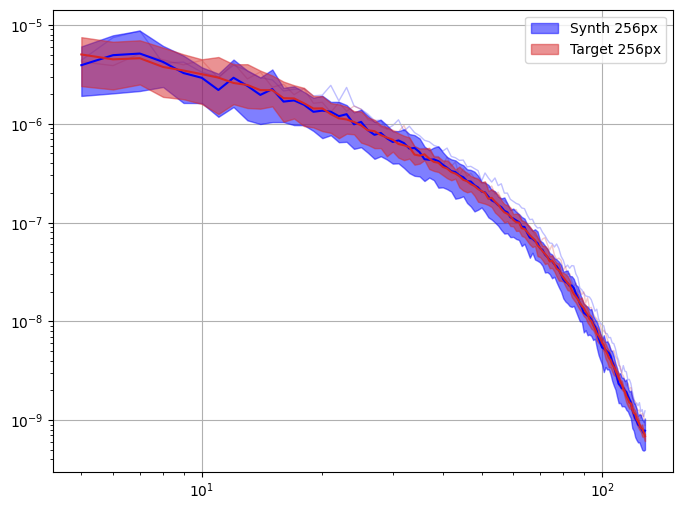

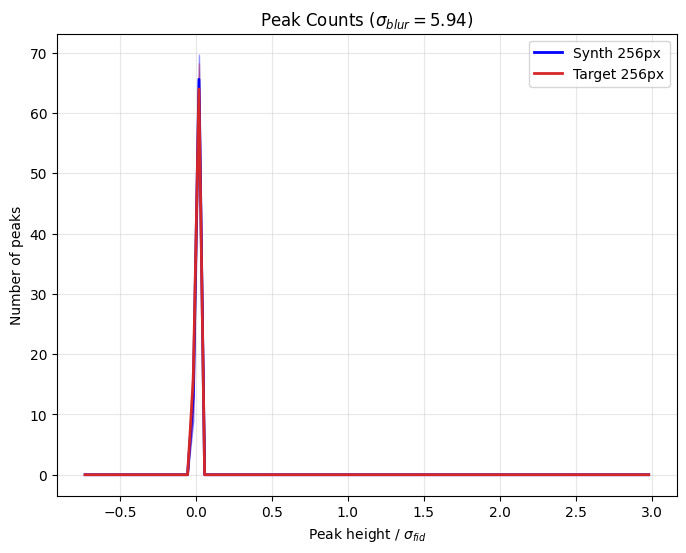

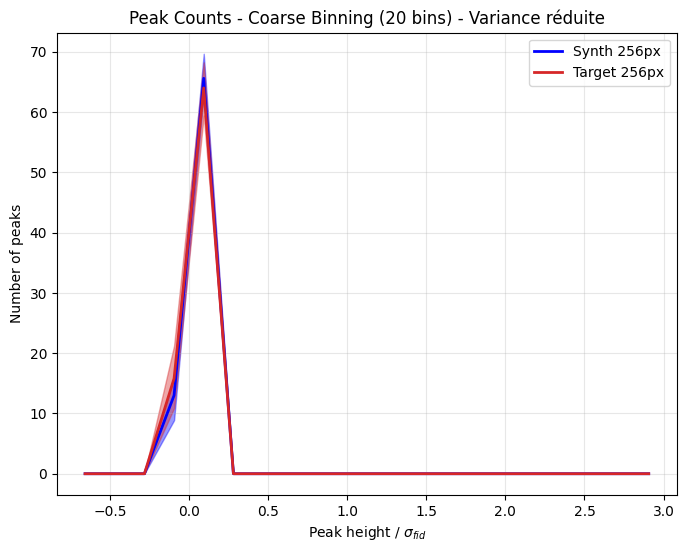

/rds/rds-clecat/generative_modelling/clean_utils_3.py:904: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.78)


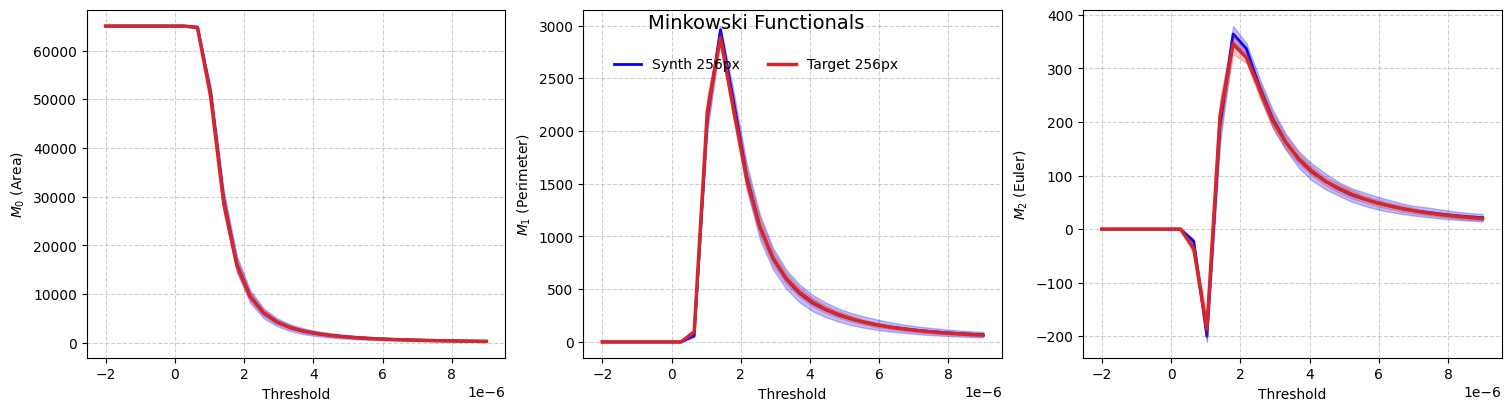

[paper_s3_s4_many_maps] 0/10
[paper_s3_s4_many_maps] 0/10


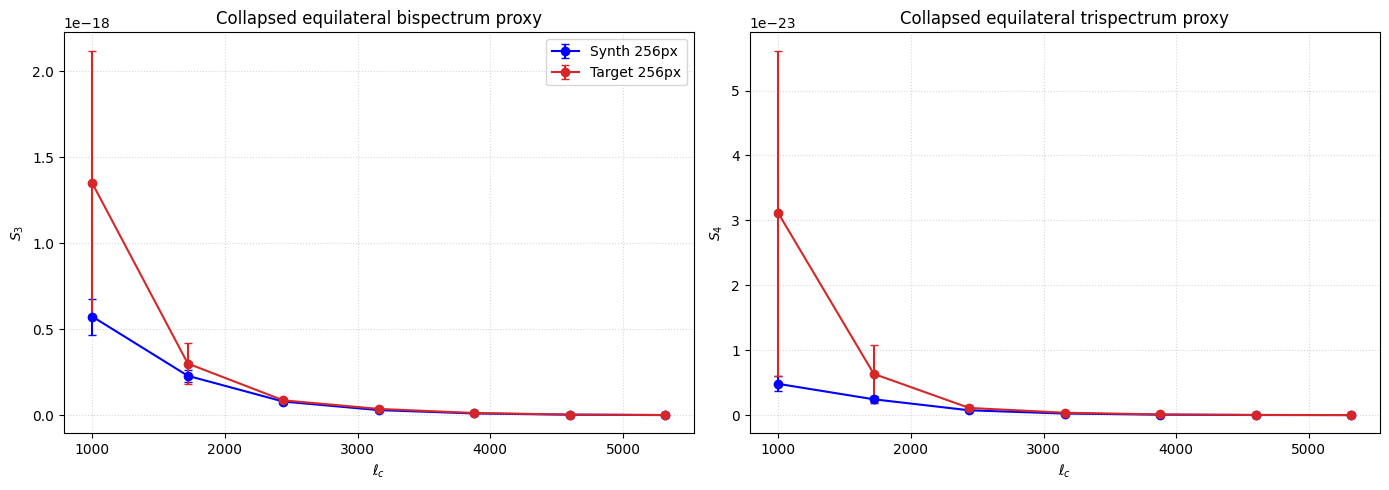

{'n_folders': 2,
 'counts': [10, 10],
 'labels': ['Synth 256px', 'Target 256px'],
 'colors': ['blue', 'tab:red'],
 'gaussian_mode': 'disabled',
 'gaussian_source_index': None,
 'gaussian_color': 'black',
 'cross_stats': False}

In [4]:
from clean_utils_3 import * 

flexible_analysis(
    [
       "/rds/rds-clecat/generative_modelling/scripts/results_20patches_14_05_cv_2000_256/raw_results_1_256/tsz",
        "/rds/rds-clecat/generative_modelling/scripts/results_20patches_14_05_cv_2000_256/raw_target_256/tsz",
    ],
    labels=["Synth 256px", "Target 256px"],
    colors=["blue", "tab:red"],
    ps_kmin=5,
    ps_kmax=128,            # Ajusté pour 256px
    ps_plot_individual_n=1,
    imshow_indices=[3, 3],
    pdf_bins=60,
    pdf_range=(-1e-5, 9e-5),
    gaussian=False,
    show=True,
    mf_min_threshold=-2e-6,
    mf_max_threshold=9e-6,
    bispectrum_paper=True,
    trispectrum_paper=True
)

# Same set up but 4000 steps in the optim loop, improves tSZ bi/trispectra but PS has small oscillations

Note that the results will be downsampled to 256 pixels (which has not been done here), meaning the Nyquist mode is $k=128$. The first and second plots differ only because they were analyzed using different functions (different apodization of the PS and no bispectrum/trispectrum in the first series), though they analyze the same patches

tsz_all.shape = (351, 512, 512)
ksz_all.shape = (351, 512, 512)
cib_all.shape = (351, 512, 512)
A_tsz = 1.94687930231972
B_tsz = -7.079570746267914e-07
tsz_all_log.shape = (351, 512, 512)
mixed_target.shape = (10, 3, 512, 512)
centered_target.shape = (10, 3, 512, 512)
channel_means.shape   = (10, 3, 1, 1)
Running synthesis on device : cuda:0 dtype : torch.float64
Initial shape for u: (10, 3, 512, 512)
Synthesis on MAIN 35766 coefficients
Replacing existing var_ref in ST_Op
Replacing existing S2_ref_sqrt_chan_diag in ST_Op
Synthesis on EXP-PS 192 coefficients
Synthesis on EXP-SCAT 35574 coefficients
[LBFGS] inner iter 100, loss = 4.321420e+02, loss_main = 1.886423e+02, loss_exp_ps = 8.500216e+01, loss_exp_scat = 1.584974e+02
[LBFGS] inner iter 200, loss = 2.888551e+02, loss_main = 1.173303e+02, loss_exp_ps = 7.045212e+01, loss_exp_scat = 1.010728e+02
[LBFGS] inner iter 300, loss = 2.491270e+02, loss_main = 1.103718e+02, loss_exp_ps = 5.943139e+01, loss_exp_scat = 7.932375e+01
[LBFGS] in

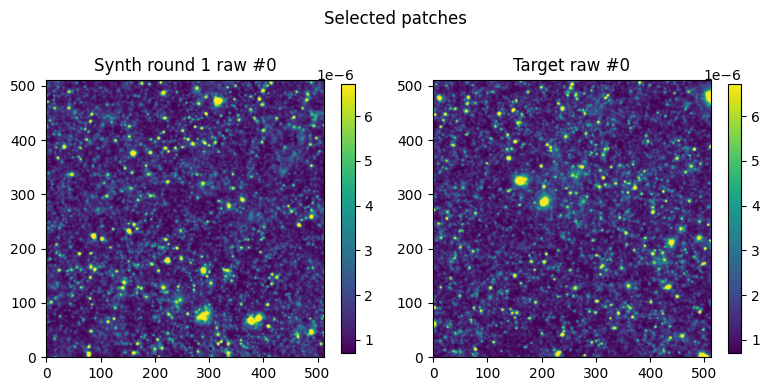

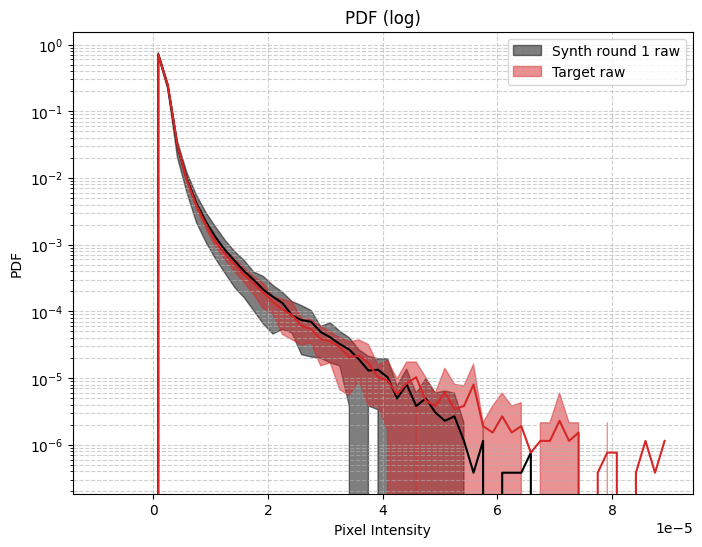

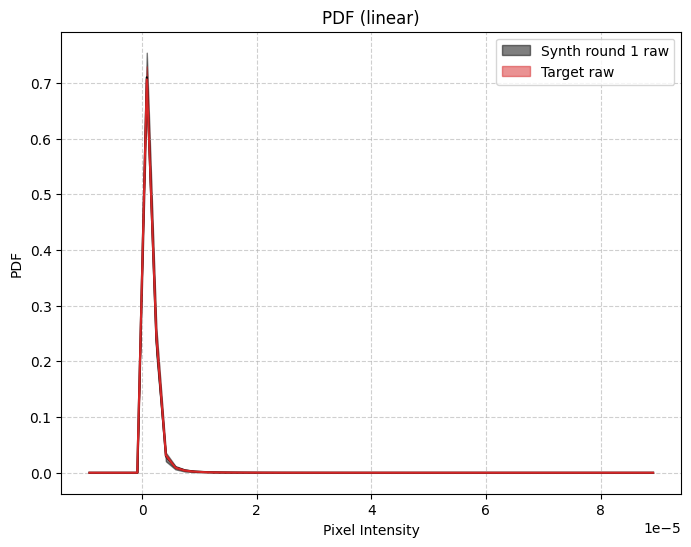

[DEBUG PS] Synth round 1 raw min= 2.4235081785526685e-10 max= 0.00016922394266669397 any>0? True any nan? False shape= (10, 252)
[DEBUG PS] Target raw min= 5.216819707338482e-10 max= 0.00021524933011119927 any>0? True any nan? False shape= (10, 252)


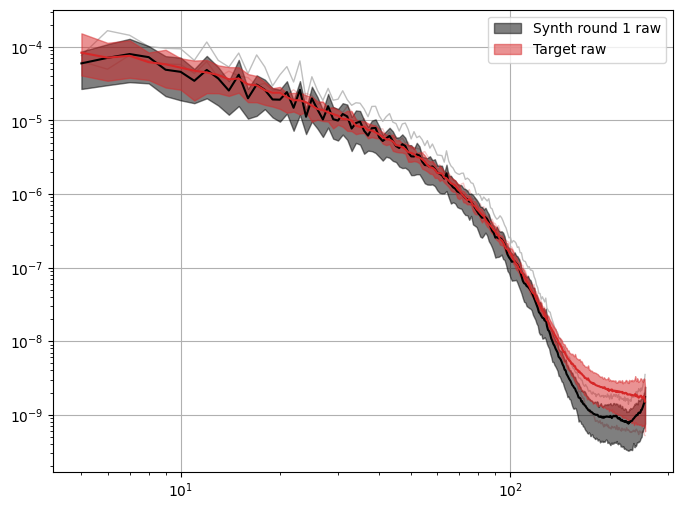

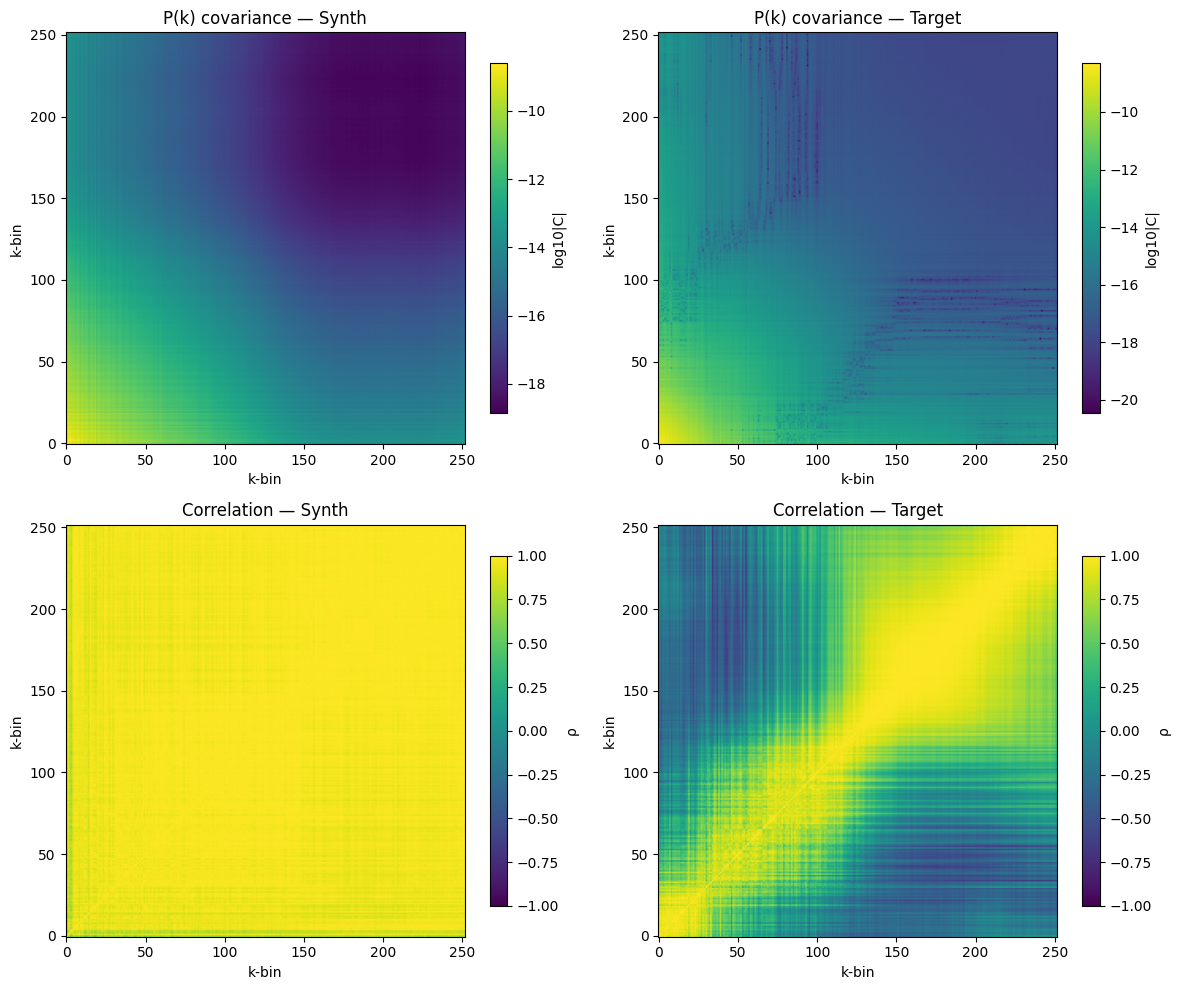

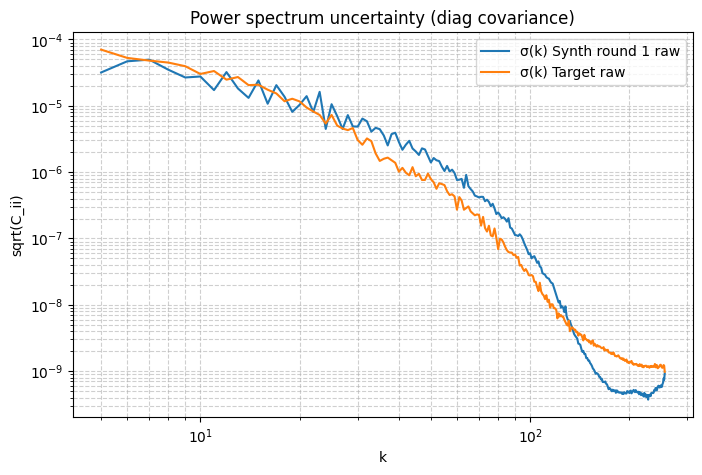

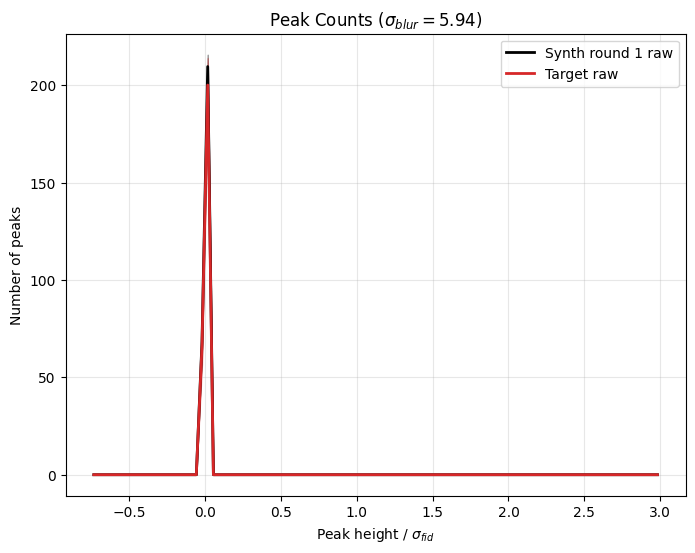

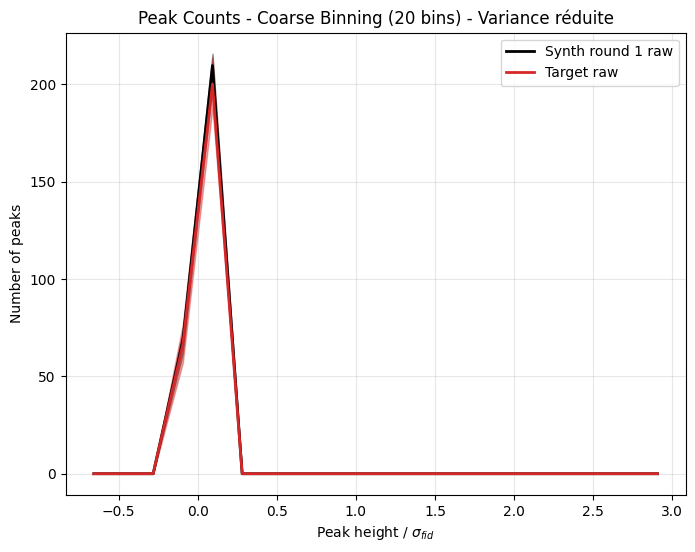

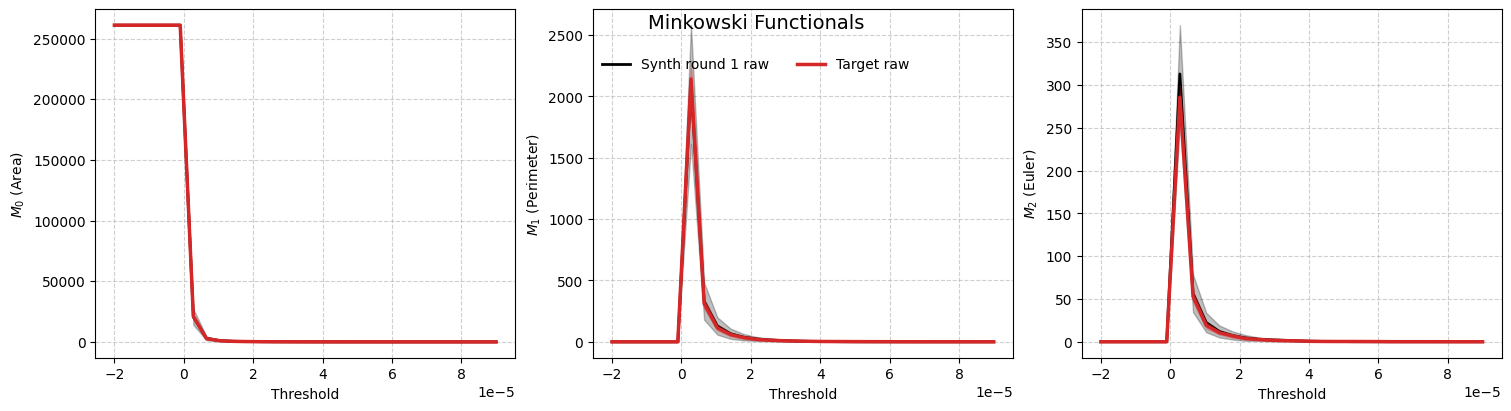

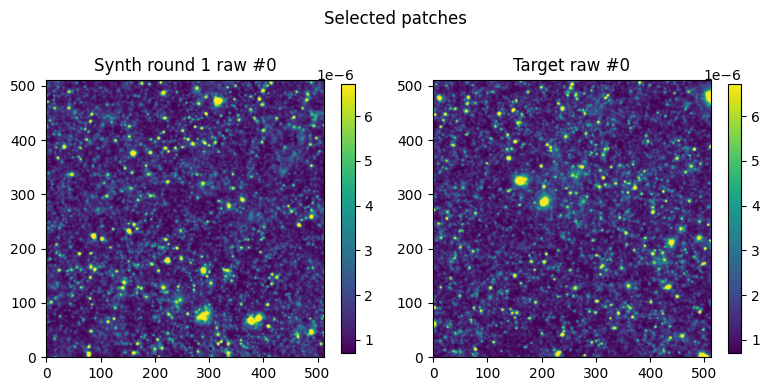

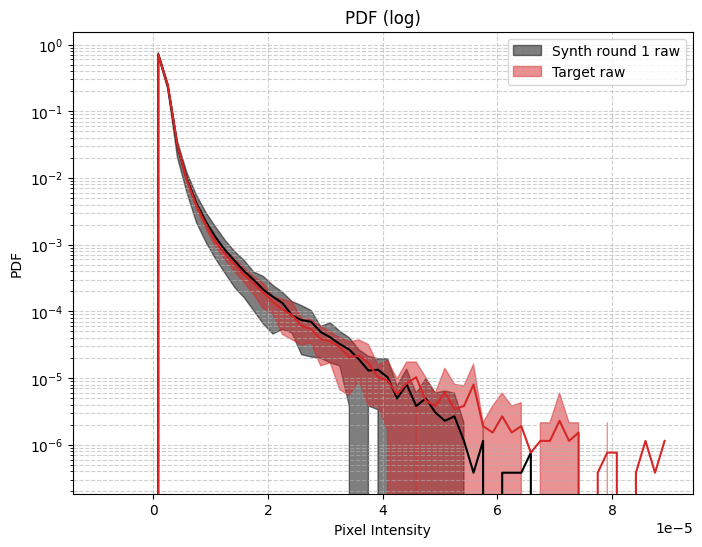

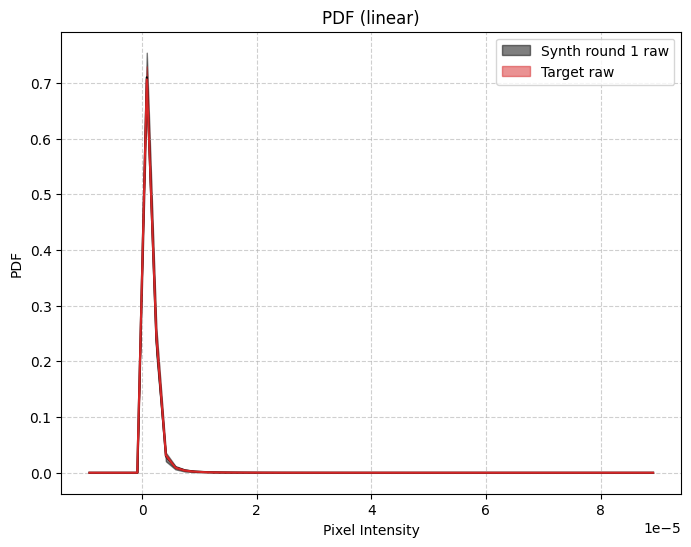

[DEBUG PS] Synth round 1 raw min= 2.343324990721195e-10 max= 0.00021085866625486396 any>0? True any nan? False shape= (10, 252)
[DEBUG PS] Target raw min= 1.6708368274644535e-10 max= 0.0002291518598753459 any>0? True any nan? False shape= (10, 252)


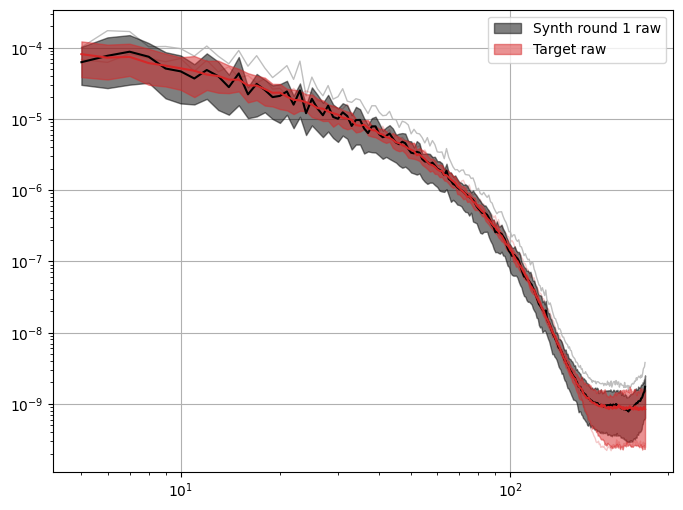

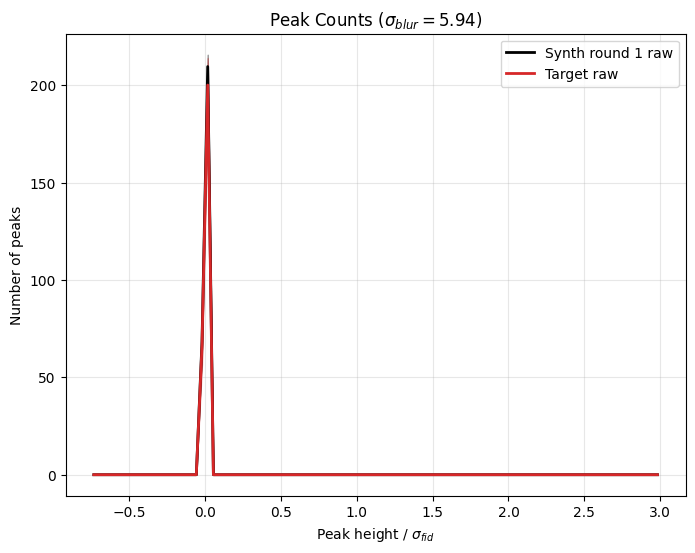

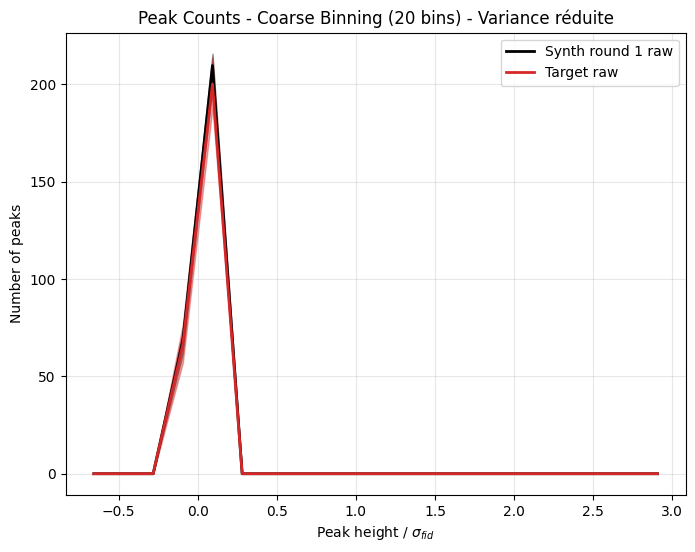

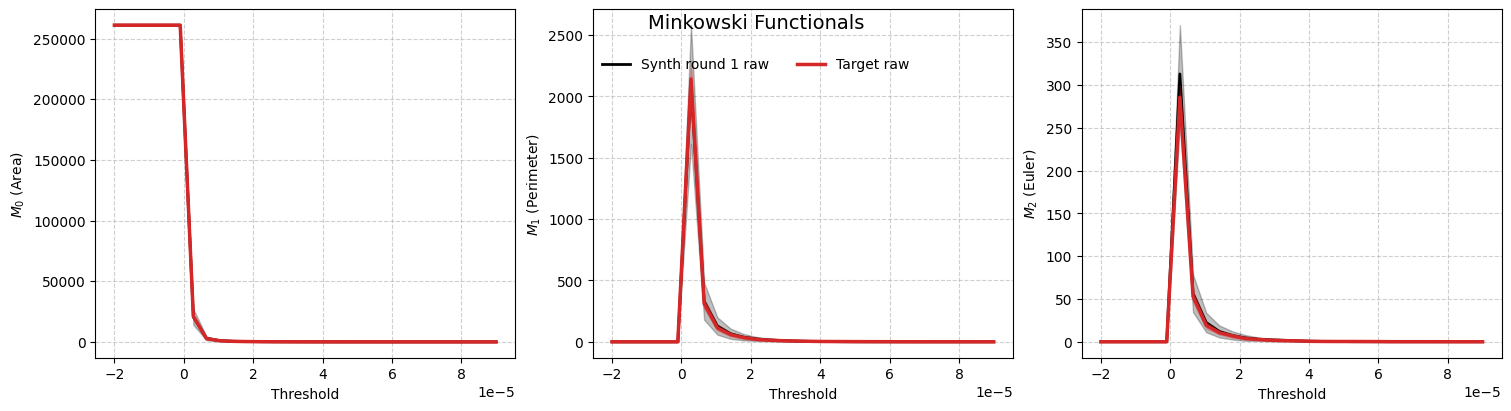

[paper_s3_s4_many_maps] 0/10
[paper_s3_s4_many_maps] 0/10


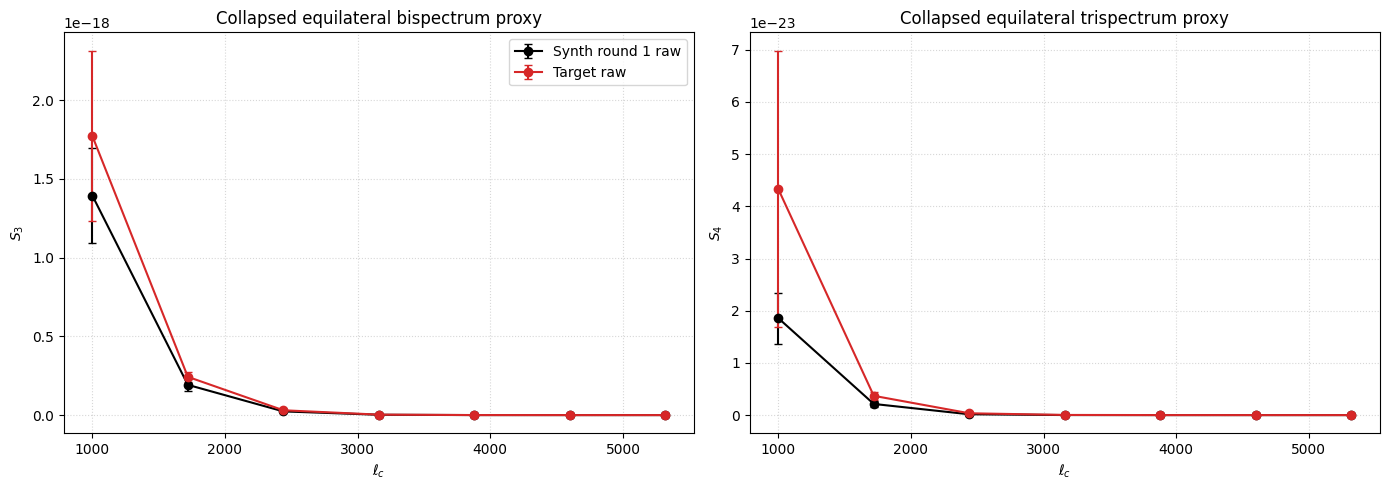

{'n_folders': 2,
 'counts': [10, 10],
 'labels': ['Synth round 1 raw', 'Target raw'],
 'colors': ['black', 'tab:red'],
 'gaussian_mode': 'disabled',
 'gaussian_source_index': None,
 'gaussian_color': 'black',
 'cross_stats': False}

In [5]:
import os
import sys
import numpy as np
import torch

# =========================================================
# Paths / imports
# =========================================================
chemin_stl_dev = os.path.join(os.getcwd(), "STL_104")
sys.path.append(os.getcwd())
sys.path.append(chemin_stl_dev)
sys.path.append("/rds/rds-clecat/generative_modelling/STL_104")

from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch
from STL_main.Synthesis_PS_ST import synthesize_from_maps
from clean_utils import find_parameters, flexible_analysis


# =========================================================
# Paramètres généraux
# =========================================================
file_base = "/rds/rds-clecat/generative_modelling/data_celia"
#base_dir = "results_mean_field_multichannel_logspace" => results already converged 
base_dir = "results_20patches_14_05_cv_4000"
n_sets = 10
nbatch = 10
mean_field = True
eps = 1e-11

os.makedirs(base_dir, exist_ok=True)


# =========================================================
# Utilitaires
# =========================================================
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def save_three_channels(arr, out_base):
    """
    arr shape = (N, 3, H, W)
    channel 0 = tsz
    channel 1 = ksz
    channel 2 = cib
    """
    tsz_dir = os.path.join(out_base, "tsz")
    ksz_dir = os.path.join(out_base, "ksz")
    cib_dir = os.path.join(out_base, "cib")

    for d in [tsz_dir, ksz_dir, cib_dir]:
        os.makedirs(d, exist_ok=True)

    for i in range(arr.shape[0]):
        np.save(os.path.join(tsz_dir, f"patch_{i:03d}.npy"), arr[i, 0].astype(np.float32))
        np.save(os.path.join(ksz_dir, f"patch_{i:03d}.npy"), arr[i, 1].astype(np.float32))
        np.save(os.path.join(cib_dir, f"patch_{i:03d}.npy"), arr[i, 2].astype(np.float32))


# =========================================================
# 1) Chargement des cartes physiques
# =========================================================
tsz_all = np.load(f"{file_base}/tsz_cut_maps.npy").astype(np.float64)
ksz_all = np.load(f"{file_base}/ksz_cut_maps.npy").astype(np.float64)
cib_all = np.load(f"{file_base}/cib353_cut_maps.npy").astype(np.float64)

print("tsz_all.shape =", tsz_all.shape)
print("ksz_all.shape =", ksz_all.shape)
print("cib_all.shape =", cib_all.shape)


# =========================================================
# 2) Log-normalisation sur tSZ seulement
# =========================================================
A_tsz, B_tsz = find_parameters(tsz_all)
tsz_all_log = np.log(A_tsz * tsz_all + B_tsz + eps)

print("A_tsz =", A_tsz)
print("B_tsz =", B_tsz)
print("tsz_all_log.shape =", tsz_all_log.shape)


# =========================================================
# 3) Construction de la target multicanal dans l’espace log
#    canal 0 = tSZ_log
#    canal 1 = kSZ raw
#    canal 2 = CIB raw
# =========================================================
mixed_target = np.stack(
    [tsz_all_log[:n_sets], ksz_all[:n_sets], cib_all[:n_sets]],
    axis=1
)

print("mixed_target.shape =", mixed_target.shape)


# =========================================================
# 4) Centrage par canal et par patch
# =========================================================
channel_means = mixed_target.mean(axis=(-2, -1), keepdims=True)
centered_target = mixed_target - channel_means

print("centered_target.shape =", centered_target.shape)
print("channel_means.shape   =", channel_means.shape)


# =========================================================
# 5) STL target
# =========================================================
data_target = STL_2D_Kernel_Torch(centered_target, pbc=False)

compute_cross_matrix = torch.tensor([
    [1, 1, 1],
    [0, 1, 1],
    [0, 0, 1]
], dtype=torch.bool)


# =========================================================
# 6) Synthèse unique : espace centered/log, AVEC contrainte exp sur tSZ
# =========================================================
u_synth_1 = synthesize_from_maps(
    data_target,
    pbc_running=True,
    nbatch=nbatch,
    mean_field=mean_field,
    compute_cross_matrix=compute_cross_matrix,
    init_data=None,          # bruit blanc
    max_iter=5000,
    lr=0.2,
    history_size=50,
    print_iter=100,
    verbose=True,
    seed=26,

    # --- branche exp activée pour le canal tSZ_log centré ---
    exp_channel=0,
    exp_A=A_tsz,
    exp_B=B_tsz,
    exp_eps=eps,
    exp_channel_mean=channel_means[:, 0:1],   # shape (2,1,1,1)

    lambda_exp_ps=1.0,
    lambda_exp_scat=1.0,
)

print("u_synth_1.shape =", u_synth_1.shape)

# =========================================================
# 7) Conversion numpy
# =========================================================
u1 = to_numpy(u_synth_1).astype(np.float64)

if u1.ndim == 3:
    u1 = u1[None, ...]

expected_shape = (
    nbatch,
    centered_target.shape[1],
    centered_target.shape[2],
    centered_target.shape[3],
)

if u1.shape != expected_shape:
    raise ValueError(f"u_synth_1 has shape {u1.shape}, expected {expected_shape}")


# =========================================================
# 8) Résultats backend = espace centré
# =========================================================
centered_results_1 = u1


# =========================================================
# 9) On remet les moyennes -> retour espace log
# =========================================================
log_results_1 = centered_results_1 + channel_means
log_target = centered_target + channel_means


# =========================================================
# 10) Délog-normalisation : retour à l’espace physique pour tSZ
# =========================================================
raw_results_1 = log_results_1.copy()
raw_target = log_target.copy()

raw_results_1[:, 0] = (np.exp(log_results_1[:, 0]) - B_tsz - eps) / A_tsz
raw_target[:, 0]    = (np.exp(log_target[:, 0])    - B_tsz - eps) / A_tsz


# =========================================================
# 11) Sauvegarde
# =========================================================
centered_target_base = os.path.join(base_dir, "centered_target")
log_target_base = os.path.join(base_dir, "log_target")
raw_target_base = os.path.join(base_dir, "raw_target")

centered_results_1_base = os.path.join(base_dir, "centered_results_1")
log_results_1_base = os.path.join(base_dir, "log_results_1")
raw_results_1_base = os.path.join(base_dir, "raw_results_1")

save_three_channels(centered_target, centered_target_base)
save_three_channels(log_target, log_target_base)
save_three_channels(raw_target, raw_target_base)

save_three_channels(centered_results_1, centered_results_1_base)
save_three_channels(log_results_1, log_results_1_base)
save_three_channels(raw_results_1, raw_results_1_base)


# =========================================================
# 12) Métadonnées
# =========================================================
np.save(os.path.join(base_dir, "A_tsz.npy"), np.array(A_tsz, dtype=np.float64))
np.save(os.path.join(base_dir, "B_tsz.npy"), np.array(B_tsz, dtype=np.float64))
np.save(os.path.join(base_dir, "channel_means.npy"), channel_means.astype(np.float64))

print("Tout est sauvegardé dans :", base_dir)
print("  centered_target    ->", centered_target_base)
print("  log_target         ->", log_target_base)
print("  raw_target         ->", raw_target_base)
print("  centered_results_1 ->", centered_results_1_base)
print("  log_results_1      ->", log_results_1_base)
print("  raw_results_1      ->", raw_results_1_base)


# =========================================================
# 13) Analyse tSZ en espace physique
# =========================================================
flexible_analysis(
    [
        os.path.join(raw_results_1_base, "tsz"),
        os.path.join(raw_target_base, "tsz"),
    ],
    labels=["Synth round 1 raw", "Target raw"],
    colors=["black", "tab:red"],
    ps_kmin=5,
    ps_kmax=256,
    ps_plot_individual_n=1,
    imshow_indices=[0, 0],
    pdf_bins=60,
    pdf_range=(-1e-5, 9e-5),
    gaussian=False,
    show=True,
    mf_min_threshold=-2e-5,
    mf_max_threshold=9e-5,
)

from clean_utils_3 import *

flexible_analysis(
    [
        os.path.join(raw_results_1_base, "tsz"),
        os.path.join(raw_target_base, "tsz"),
    ],
    labels=["Synth round 1 raw", "Target raw"],
    colors=["black", "tab:red"],
    ps_kmin=5,
    ps_kmax=256,
    ps_plot_individual_n=1,
    imshow_indices=[0, 0],
    pdf_bins=60,
    pdf_range=(-1e-5, 9e-5),
    gaussian=False,
    show=True,
    mf_min_threshold=-2e-5,
    mf_max_threshold=9e-5,
    bispectrum_paper = True,
    trispectrum_paper=True
)